<a href="https://colab.research.google.com/github/jasonhan0916/helloworld/blob/main/hrrr_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install herbie-data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 57.8 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 95.9 MB/s eta 0:00:00


In [ ]:
!pip install metpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 8.7 MB/s eta 0:00:00


In [ ]:
from herbie import Herbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

H = Herbie(
    "2021-08-20",
    model="hrrr",
    product="sfc",
    fxx=19,
)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2021-Aug-20 00:00 UTC F19 ┊ GRIB2 @ aws ┊ IDX @ aws


In [ ]:
# Show available products
H.PRODUCTS

{'sfc': '2D surface level fields; 3-km resolution',
 'prs': '3D pressure level fields; 3-km resolution',
 'nat': 'Native level fields; 3-km resolution',
 'subh': 'Subhourly grids; 3-km resolution'}

In [ ]:
# Show actual URL sources Herbie searches
H.SOURCES

{'aws': 'https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr.20210820/conus/hrrr.t00z.wrfsfcf19.grib2',
 'nomads': 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/hrrr/prod/hrrr.20210820/conus/hrrr.t00z.wrfsfcf19.grib2',
 'google': 'https://storage.googleapis.com/high-resolution-rapid-refresh/hrrr.20210820/conus/hrrr.t00z.wrfsfcf19.grib2',
 'azure': 'https://noaahrrr.blob.core.windows.net/hrrr/hrrr.20210820/conus/hrrr.t00z.wrfsfcf19.grib2',
 'pando': 'https://pando-rgw01.chpc.utah.edu/hrrr/sfc/20210820/hrrr.t00z.wrfsfcf19.grib2',
 'pando2': 'https://pando-rgw02.chpc.utah.edu/hrrr/sfc/20210820/hrrr.t00z.wrfsfcf19.grib2'}

In [ ]:
H.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,694031.0,0-694031,2021-08-20,2021-08-20 19:00:00,REFC,entire atmosphere,19 hour fcst,:REFC:entire atmosphere:19 hour fcst
1,2,694032,993737.0,694032-993737,2021-08-20,2021-08-20 19:00:00,RETOP,cloud top,19 hour fcst,:RETOP:cloud top:19 hour fcst
2,3,993738,1649378.0,993738-1649378,2021-08-20,2021-08-20 19:00:00,var discipline=0 center=7 local_table=1 parmca...,entire atmosphere,19 hour fcst,:var discipline=0 center=7 local_table=1 parmc...
3,4,1649379,1996273.0,1649379-1996273,2021-08-20,2021-08-20 19:00:00,VIL,entire atmosphere,19 hour fcst,:VIL:entire atmosphere:19 hour fcst
4,5,1996274,3523444.0,1996274-3523444,2021-08-20,2021-08-20 19:00:00,VIS,surface,19 hour fcst,:VIS:surface:19 hour fcst
...,...,...,...,...,...,...,...,...,...,...
168,169,168486297,168486529.0,168486297-168486529,2021-08-20,2021-08-20 19:00:00,ICEC,surface,19 hour fcst,:ICEC:surface:19 hour fcst
169,170,168486530,170267801.0,168486530-170267801,2021-08-20,2021-08-20 19:00:00,SBT123,top of atmosphere,19 hour fcst,:SBT123:top of atmosphere:19 hour fcst
170,171,170267802,172138787.0,170267802-172138787,2021-08-20,2021-08-20 19:00:00,SBT124,top of atmosphere,19 hour fcst,:SBT124:top of atmosphere:19 hour fcst
171,172,172138788,173793085.0,172138788-173793085,2021-08-20,2021-08-20 19:00:00,SBT113,top of atmosphere,19 hour fcst,:SBT113:top of atmosphere:19 hour fcst


In [ ]:
ds = H.xarray("TMP:2 m above")
ds

<xarray.Dataset> Size: 38MB
Dimensions:              (y: 1059, x: 1799)
Coordinates:
    time                 datetime64[ns] 8B 2021-08-20
    step                 timedelta64[ns] 8B 19:00:00
    heightAboveGround    float64 8B 2.0
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time           datetime64[ns] 8B 2021-08-20T19:00:00
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Data variables:
    t2m                  (y, x) float32 8MB 296.2 296.2 296.2 ... 291.7 291.7
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   hrrr
    product:                 sfc
    description:             High-Resolution Rapid Refresh - CONUS
    remote_grib:             https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr....
    local_grib:              /root/data/hrrr/20210820/subset_1dbcfd54__hrrr.t...
    search:                  TMP:2 m above

Text(1.0, 1.0, '2 metre temperature')

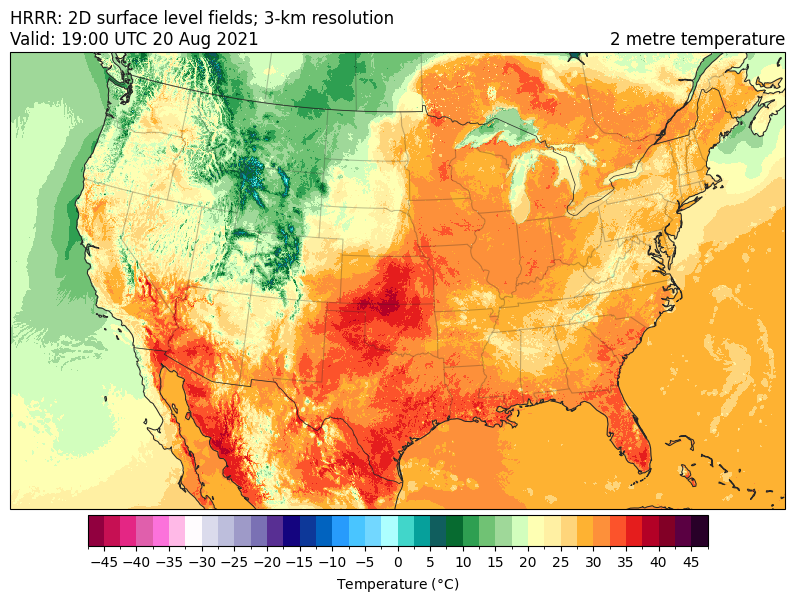

In [ ]:
ax = EasyMap("50m", crs=ds.herbie.crs, figsize=[10, 8]).BORDERS().STATES().ax

p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t2m - 273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)
plt.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.01,
    shrink=0.8,
    **paint.NWSTemperature.cbar_kwargs2,
)

ax.set_title(
    f"{ds.model.upper()}: {H.product_description}\nValid: {ds.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}",
    loc="left",
)
ax.set_title(ds.t2m.GRIB_name, loc="right")